# Custom Operator Experiment

The package lets a custom branch replace $L_\theta$ while preserving the
SILVA fixed-point structure:

$$
z^\star=\sigma\{S_\theta(x)+L_{\psi}(z^\star)+G_\theta(z^\star)\}.
$$

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
from silva_networks import SILVAGraphNetwork, SolverConfig

class SignedLocal(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.proj = torch.nn.Linear(dim, dim, bias=False)

    def forward(self, z, edge_index=None):
        messages = torch.tanh(self.proj(z))
        if edge_index is None:
            return messages
        src, dst = edge_index
        out = torch.zeros_like(messages)
        out.index_add_(0, dst, messages[src])
        return out

The custom module implements a local operator

$$
L_\psi:\mathbb R^{N\times d}\to\mathbb R^{N\times d}.
$$

The wrapper passes `edge_index` when it is available. The only hard contract is
that the returned tensor has the same shape as the recurrent state.

In [3]:
torch.manual_seed(4)
x = torch.randn(12, 6)
y = (x[:, 0] + 0.5 * x[:, 1] > 0).long()
edge_index = torch.tensor([list(range(11)), list(range(1, 12))], dtype=torch.long)

model = SILVAGraphNetwork(
    in_dim=6,
    hidden_dims=[16, 16],
    out_dim=2,
    task="node",
    local=lambda dim, index: SignedLocal(dim),
    global_term="mean",
    config=SolverConfig(solver="picard", max_iter=6, alpha=0.5),
)

Training does not need a special loop. The equilibrium layer is part of an
ordinary PyTorch module, so `loss.backward()` differentiates through the solver
steps used in the forward pass.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for step in range(5):
    logits = model(x, edge_index=edge_index)
    loss = torch.nn.functional.cross_entropy(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))
    print(step, float(loss.detach()))

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


0 0.5560581684112549
1 0.4298062324523926
2 0.337056428194046
3 0.27874329686164856
4 0.21921612322330475


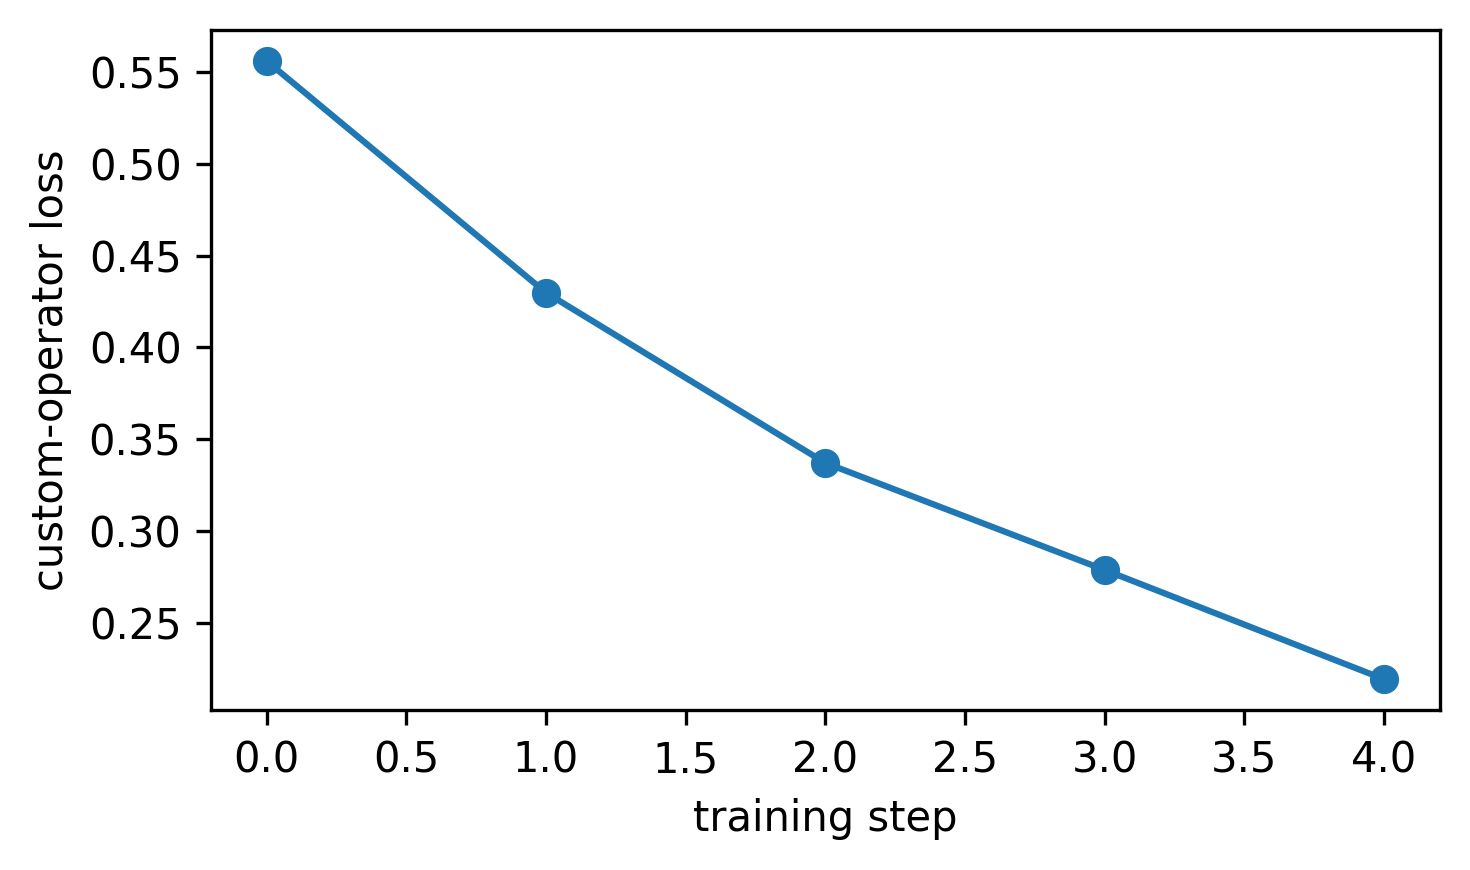

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

plt.figure(figsize=(5, 3))
plt.plot(losses, marker="o")
plt.xlabel("training step")
plt.ylabel("custom-operator loss")
plt.tight_layout()

## Citation and Sources

If this notebook or package is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.0.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770099
```

When the work is connected to the SILVA Networks paper, cite the paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background references used in the tutorial suite include:

- Deep Equilibrium Models, Bai, Kolter, and Koltun, NeurIPS 2019:
  https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models, Bai, Koltun, and Kolter, NeurIPS 2020:
  https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization, Bai, Koltun, and
  Kolter, ICML 2021: https://arxiv.org/abs/2106.14342
- Graph Attention Networks, Velickovic et al., ICLR 2018:
  https://arxiv.org/abs/1710.10903
- Attention Is All You Need, Vaswani et al., 2017:
  https://arxiv.org/abs/1706.03762